In [1]:
import pandas as pd

filename = 'heart.csv'
df = pd.read_csv(filename)
df.head(1)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0


In [2]:
input_cols = df.columns.to_list()
input_cols.remove('FastingBS')
input_cols.remove('HeartDisease')

target_col = 'HeartDisease'

input_cols, target_col

(['Age',
  'Sex',
  'ChestPainType',
  'RestingBP',
  'Cholesterol',
  'RestingECG',
  'MaxHR',
  'ExerciseAngina',
  'Oldpeak',
  'ST_Slope'],
 'HeartDisease')

In [3]:
import numpy as np

In [4]:
numerical_cols = df[input_cols].select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = df[input_cols].select_dtypes(include=['object']).columns.tolist()
numerical_cols, cat_cols

(['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak'],
 ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope'])

In [5]:
df[numerical_cols].describe()

,Age,RestingBP,Cholesterol,MaxHR,Oldpeak
count,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,136.809368,0.887364
std,9.432617,18.514154,109.384145,25.460334,1.066570
min,28.000000,0.000000,0.000000,60.000000,-2.600000
25%,47.000000,120.000000,173.250000,120.000000,0.000000
50%,54.000000,130.000000,223.000000,138.000000,0.600000
75%,60.000000,140.000000,267.000000,156.000000,1.500000
max,77.000000,200.000000,603.000000,202.000000,6.200000


In [6]:
from sklearn.model_selection import train_test_split
X = df[input_cols]
y = df[target_col]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)
X_train.shape, X_test.shape

((826, 10), (92, 10))

In [7]:
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
ohe.fit(X_train[cat_cols])
ohe.categories_

[array(['F', 'M'], dtype=object),
 array(['ASY', 'ATA', 'NAP', 'TA'], dtype=object),
 array(['LVH', 'Normal', 'ST'], dtype=object),
 array(['N', 'Y'], dtype=object),
 array(['Down', 'Flat', 'Up'], dtype=object)]

In [8]:
# fitting the encoded columns and removing the original categorical columns
X_train_ohe = ohe.transform(X_train[cat_cols])
X_test_ohe = ohe.transform(X_test[cat_cols])

In [9]:
input_cols_final = numerical_cols + ohe.get_feature_names_out(cat_cols).tolist()
input_cols_final

['Age',
 'RestingBP',
 'Cholesterol',
 'MaxHR',
 'Oldpeak',
 'Sex_F',
 'Sex_M',
 'ChestPainType_ASY',
 'ChestPainType_ATA',
 'ChestPainType_NAP',
 'ChestPainType_TA',
 'RestingECG_LVH',
 'RestingECG_Normal',
 'RestingECG_ST',
 'ExerciseAngina_N',
 'ExerciseAngina_Y',
 'ST_Slope_Down',
 'ST_Slope_Flat',
 'ST_Slope_Up']

In [10]:
X_train_final = pd.DataFrame(X_train_ohe, columns=ohe.get_feature_names_out(cat_cols), index=X_train.index)
X_train_final[numerical_cols] = X_train[numerical_cols]
X_test_final = pd.DataFrame(X_test_ohe, columns=ohe.get_feature_names_out(cat_cols), index=X_test.index)
X_test_final[numerical_cols] = X_test[numerical_cols]
X_train_final.head()

,Sex_F,Sex_M,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up,Age,RestingBP,Cholesterol,MaxHR,Oldpeak
557,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,56,137,208,122,1.8
260,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,46,140,275,165,0.0
235,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,39,120,200,160,1.0
218,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,55,140,196,150,0.0
382,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,43,115,0,145,2.0


In [11]:
from sklearn.tree import DecisionTreeClassifier , plot_tree

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train_final, y_train)
model.score(X_test_final, y_test)

0.7717391304347826

In [12]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_final, y_train)
model.score(X_test_final, y_test)

0.8913043478260869

In [13]:
model.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': 42,
 'verbose': 0,
 'warm_start': False}

In [14]:
def max_depth_error(md):
    model = RandomForestClassifier(max_depth=md, random_state=42)
    model.fit(X_train_final, y_train)
    error = 1 - model.score(X_test_final, y_test)
    return {'max_depth': md, 'error': error}

In [15]:
max_depth_error_df = pd.DataFrame([max_depth_error(md) for md in range(1,31)])
max_depth_error_df.head()

,max_depth,error
0,1,0.163043
1,2,0.152174
2,3,0.130435
3,4,0.119565
4,5,0.108696


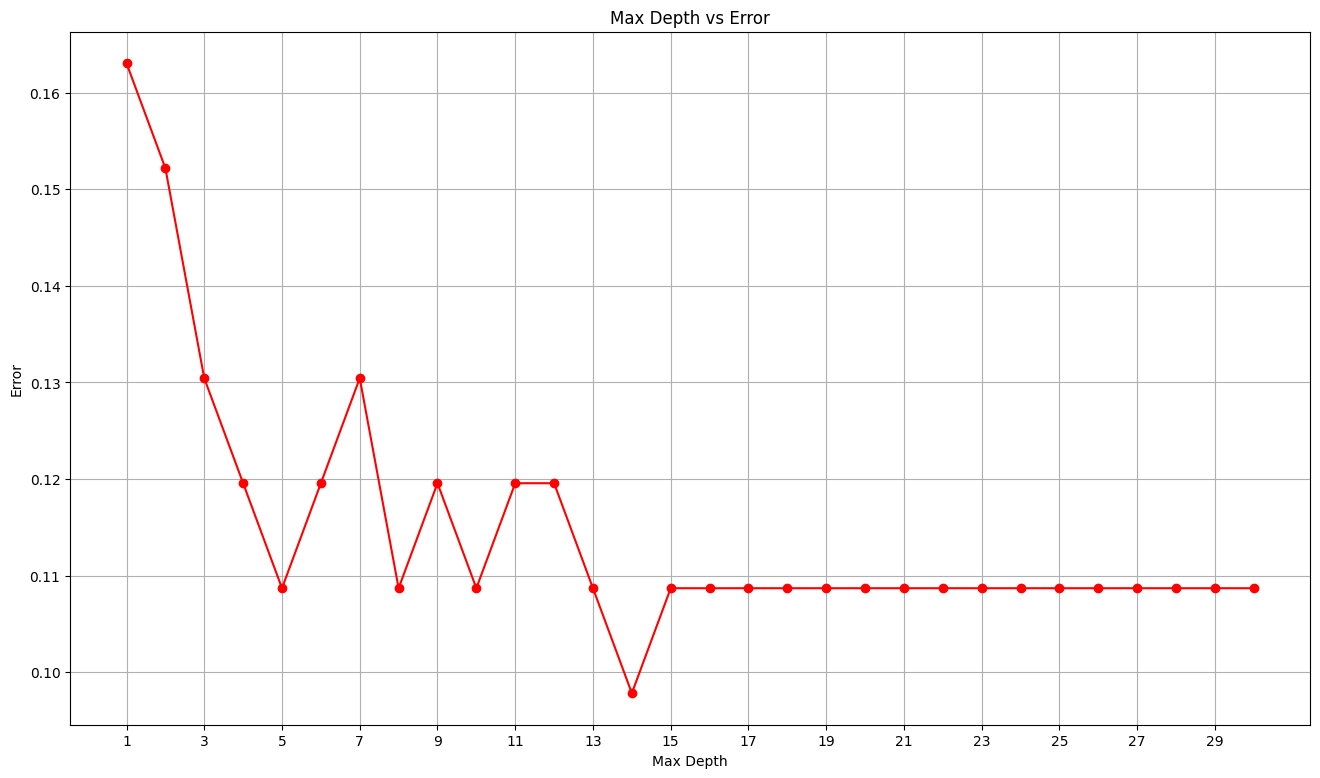

In [16]:
import matplotlib.pyplot as plt
plt.figure(figsize=(16,9))
plt.plot(max_depth_error_df['max_depth'], max_depth_error_df['error'], marker = 'o',color = 'red')
plt.title('Max Depth vs Error')
plt.xlabel('Max Depth')
plt.ylabel('Error')
plt.xticks([i for i in range(1,31,2)])
plt.grid()
plt.show()

In [17]:
# max_depth = 14 gives least error
model = RandomForestClassifier(max_depth=14, max_features = 'log2',random_state=42)
model.fit(X_train_final, y_train)
model.score(X_test_final, y_test)

0.9021739130434783

In [19]:
import warnings
warnings.filterwarnings('ignore')

In [21]:
# lightgbm boosting
from lightgbm import LGBMClassifier

lgb_model = LGBMClassifier(
    n_estimators=200,
    random_state=42)
lgb_model.fit(X_train_final, y_train)
warnings.filterwarnings('ignore')

[LightGBM] [Info] Number of positive: 454, number of negative: 372
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000111 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 391
[LightGBM] [Info] Number of data points in the train set: 826, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.549637 -> initscore=0.199203
[LightGBM] [Info] Start training from score 0.199203
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


In [22]:
lgb_model.score(X_test_final, y_test)

0.8369565217391305

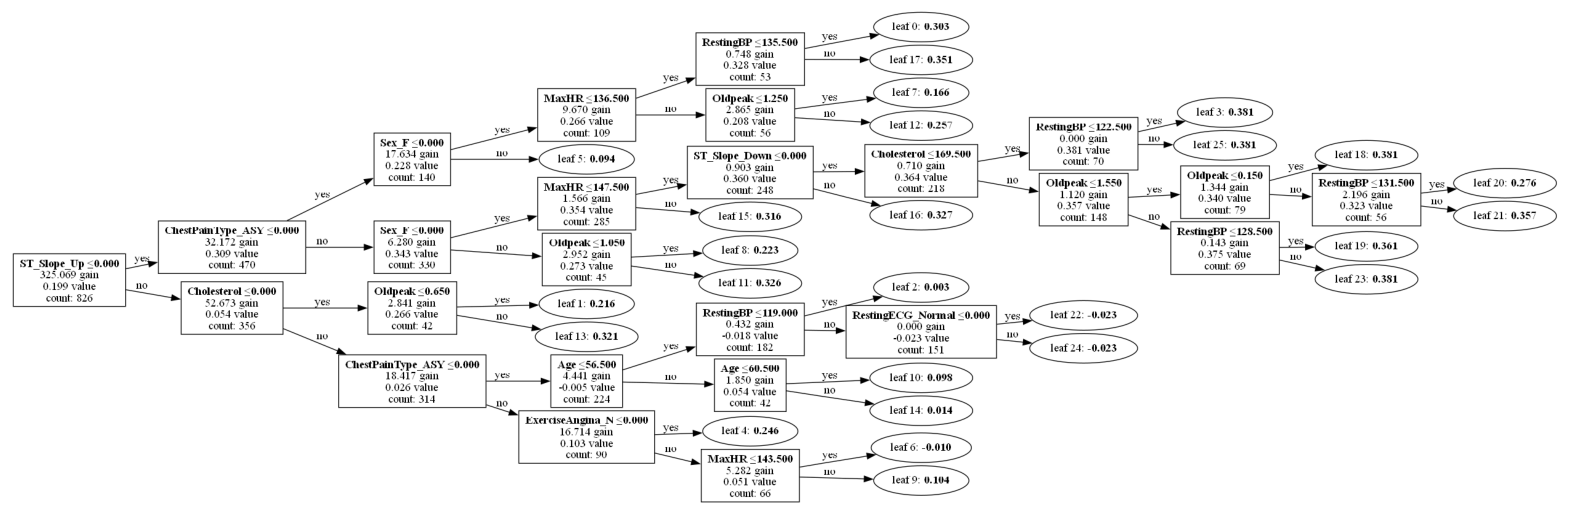

In [24]:
import lightgbm as lgb
ax = lgb.plot_tree(lgb_model, tree_index=0, figsize=(20, 10), show_info=['split_gain', 'internal_value', 'internal_count'])
plt.show()